- Luis Enrique
- Juan Ospina
- David Venté

In [ ]:
# Load drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Se cargan las diferentes dependencias necesarias
import librosa
# from spec_augment import SpecAugment
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from keras.models import Sequential
from keras.layers import Dense, Conv1D, Flatten, MaxPooling1D


import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from scipy.io import wavfile

from IPython.display import display, Audio

## Cargue

In [ ]:
clases = ["Organico", "Desecho", "Papel", "Plastico", "Pilas"]

In [ ]:
training_base_path = "/content/drive/MyDrive/UAO/7° Semestre/IA Embebidos/ia_embebidos_project_2/training/"
testing_base_path = "/content/drive/MyDrive/UAO/7° Semestre/IA Embebidos/ia_embebidos_project_2/testing/"
DatosTrainfin = None
DatosTestfin = None
LabelsTrainfin = None
LabelsTestfin = None

In [ ]:
sample_rate_objetivo = 16000
duracion_objetivo = 1
muestras_objetivo = sample_rate_objetivo * duracion_objetivo

In [ ]:
muestras_por_clase = 3
duracion_segundos = 1
tiempo = np.linspace(0, duracion_segundos, sample_rate_objetivo * duracion_segundos)

In [ ]:
def cargar_datos(base_path):
  Datosfin = None
  Labelsfin = None
  for idx, clase in enumerate(clases):
    archivos = [f for f in os.listdir(base_path) if f.startswith(f"{clase}.") and f.endswith(".wav")]
    archivos.sort()

    Datos = None  # Almacena los datos de esta clase

    for archivo in archivos:
      ruta_archivo = os.path.join(base_path, archivo)

      try:
        sr, data = wavfile.read(ruta_archivo)

        if sr != sample_rate_objetivo:
          print(f"Archivo {archivo} tiene una tasa de muestreo diferente: {sr}. Se ignora.")
          continue

        if data.ndim > 1:
          data = data[:, 0]  # Solo un canal si es estéreo

        # Asegurar 1 segundos exactos
        if len(data) < muestras_objetivo:
          data = np.pad(data, (0, muestras_objetivo - len(data)), mode='constant')
        else:
          data = data[:muestras_objetivo]

        data = data.astype(np.float32) / 32768.0  # Normalizar si está en int16
        data = data.reshape(1, -1)

        Datos = data if Datos is None else np.concatenate((Datos, data), axis=0)

      except Exception as e:
        print(f"Error leyendo {archivo}: {e}")

    print(f"Clase {clase}: {Datos.shape if Datos is not None else (0, muestras_objetivo)}")

    # Concatenar con conjunto final
    if Datos is not None:
      etiquetas = np.full((Datos.shape[0],), idx)
      Datosfin = Datos if Datosfin is None else np.concatenate((Datosfin, Datos), axis=0)
      Labelsfin = etiquetas if Labelsfin is None else np.concatenate((Labelsfin, etiquetas), axis=0)
  return Datosfin, Labelsfin

### Train

In [ ]:
DatosTrainfin, LabelsTrainfin = cargar_datos(training_base_path)

<ipython-input-7-af51318b252a>:14: WavFileWarning: Reached EOF prematurely; finished at 32044 bytes, expected 32052 bytes from header.
  sr, data = wavfile.read(ruta_archivo)


Clase Organico: (130, 16000)


<ipython-input-7-af51318b252a>:14: WavFileWarning: Reached EOF prematurely; finished at 643116 bytes, expected 643124 bytes from header.
  sr, data = wavfile.read(ruta_archivo)


Clase Desecho: (130, 16000)


<ipython-input-7-af51318b252a>:14: WavFileWarning: Reached EOF prematurely; finished at 30590 bytes, expected 30598 bytes from header.
  sr, data = wavfile.read(ruta_archivo)


Clase Papel: (130, 16000)
Clase Plastico: (130, 16000)
Clase Pilas: (130, 16000)


In [ ]:
print("Tamaño total de los datos:", DatosTrainfin.shape)
print("Tamaño total de las etiquetas:", LabelsTrainfin.shape)

Tamaño total de los datos: (650, 16000)
Tamaño total de las etiquetas: (650,)


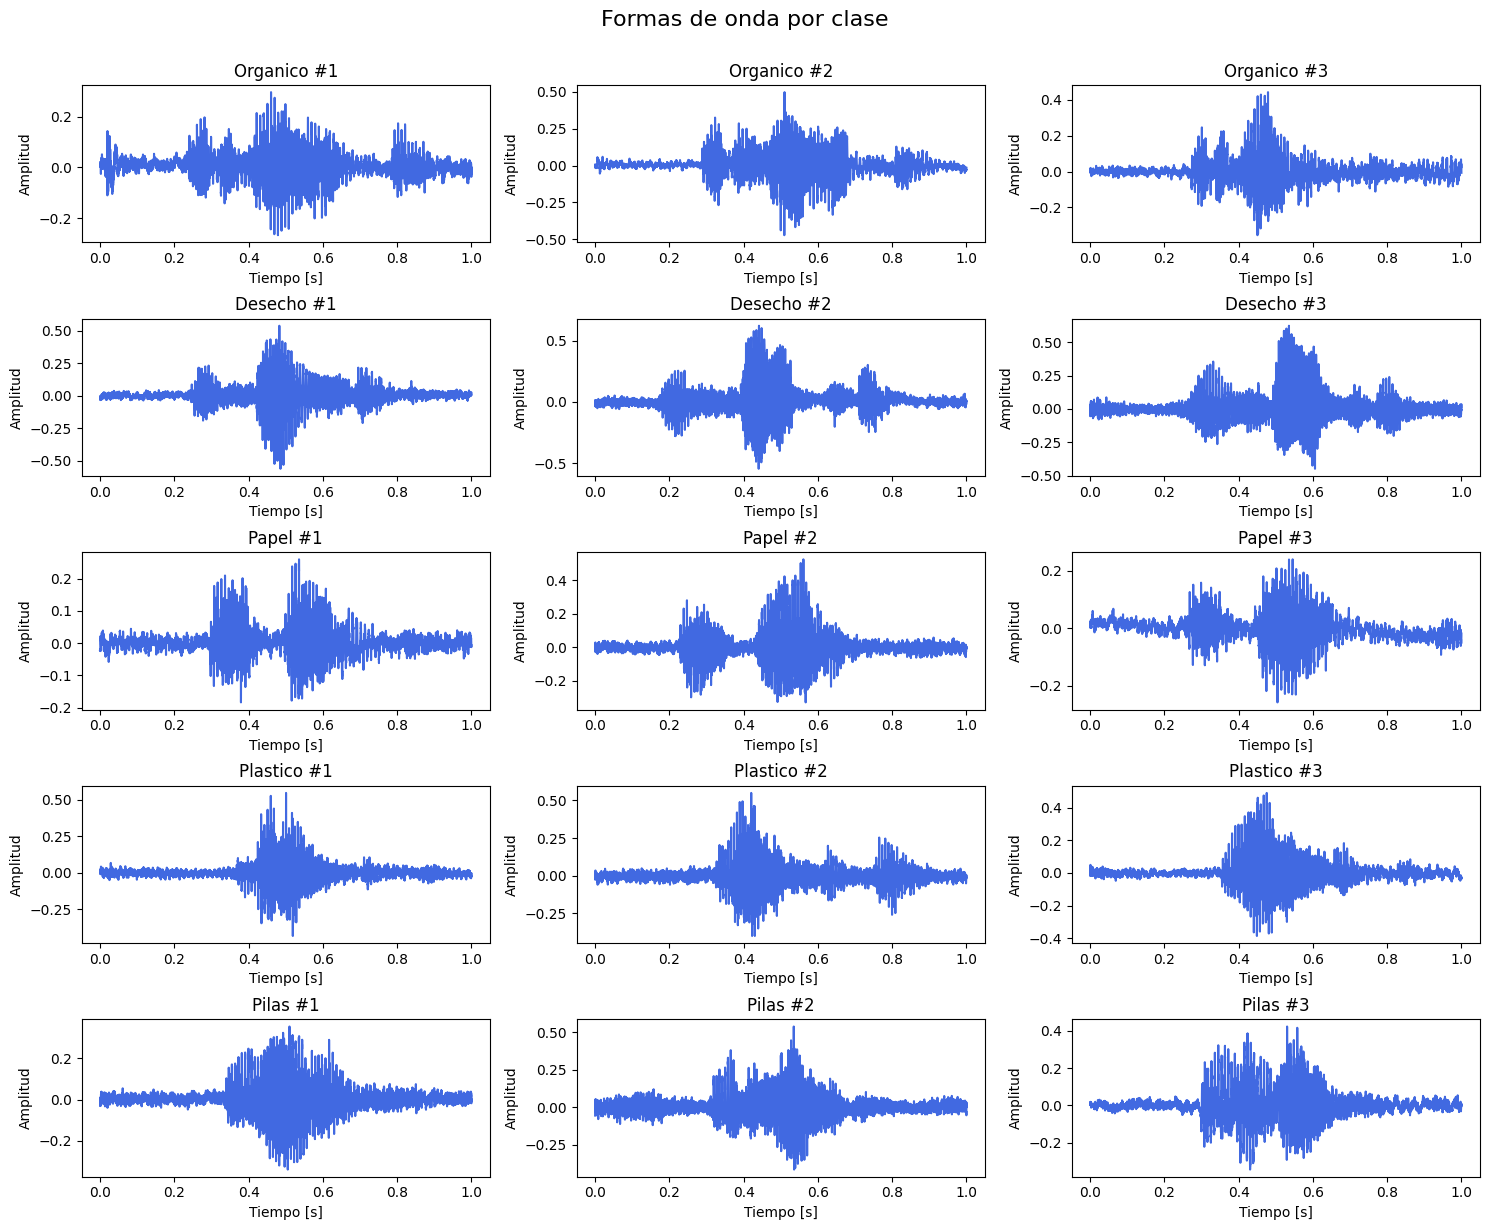

In [ ]:
plt.figure(figsize=(15, len(clases) * 2.5))

for i, clase in enumerate(clases):
  indices = np.where(LabelsTrainfin == i)[0]
  seleccionados = np.random.choice(indices, muestras_por_clase, replace=False)

  for j, idx in enumerate(seleccionados):
    plt_idx = i * muestras_por_clase + j + 1
    plt.subplot(len(clases), muestras_por_clase, plt_idx)
    plt.plot(tiempo, DatosTrainfin[idx], color='royalblue')
    plt.title(f"{clase} #{j+1}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.tight_layout()

plt.suptitle("Formas de onda por clase", fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()

### Test

In [ ]:
DatosTestfin, LabelsTestfin = cargar_datos(testing_base_path)

<ipython-input-7-af51318b252a>:14: WavFileWarning: Reached EOF prematurely; finished at 32044 bytes, expected 32052 bytes from header.
  sr, data = wavfile.read(ruta_archivo)


Clase Organico: (20, 16000)
Clase Desecho: (20, 16000)
Clase Papel: (20, 16000)
Clase Plastico: (20, 16000)
Clase Pilas: (20, 16000)


<ipython-input-7-af51318b252a>:14: WavFileWarning: Reached EOF prematurely; finished at 33708 bytes, expected 33716 bytes from header.
  sr, data = wavfile.read(ruta_archivo)


In [ ]:
print("Tamaño total de los datos:", DatosTestfin.shape)
print("Tamaño total de las etiquetas:", LabelsTestfin.shape)

Tamaño total de los datos: (100, 16000)
Tamaño total de las etiquetas: (100,)


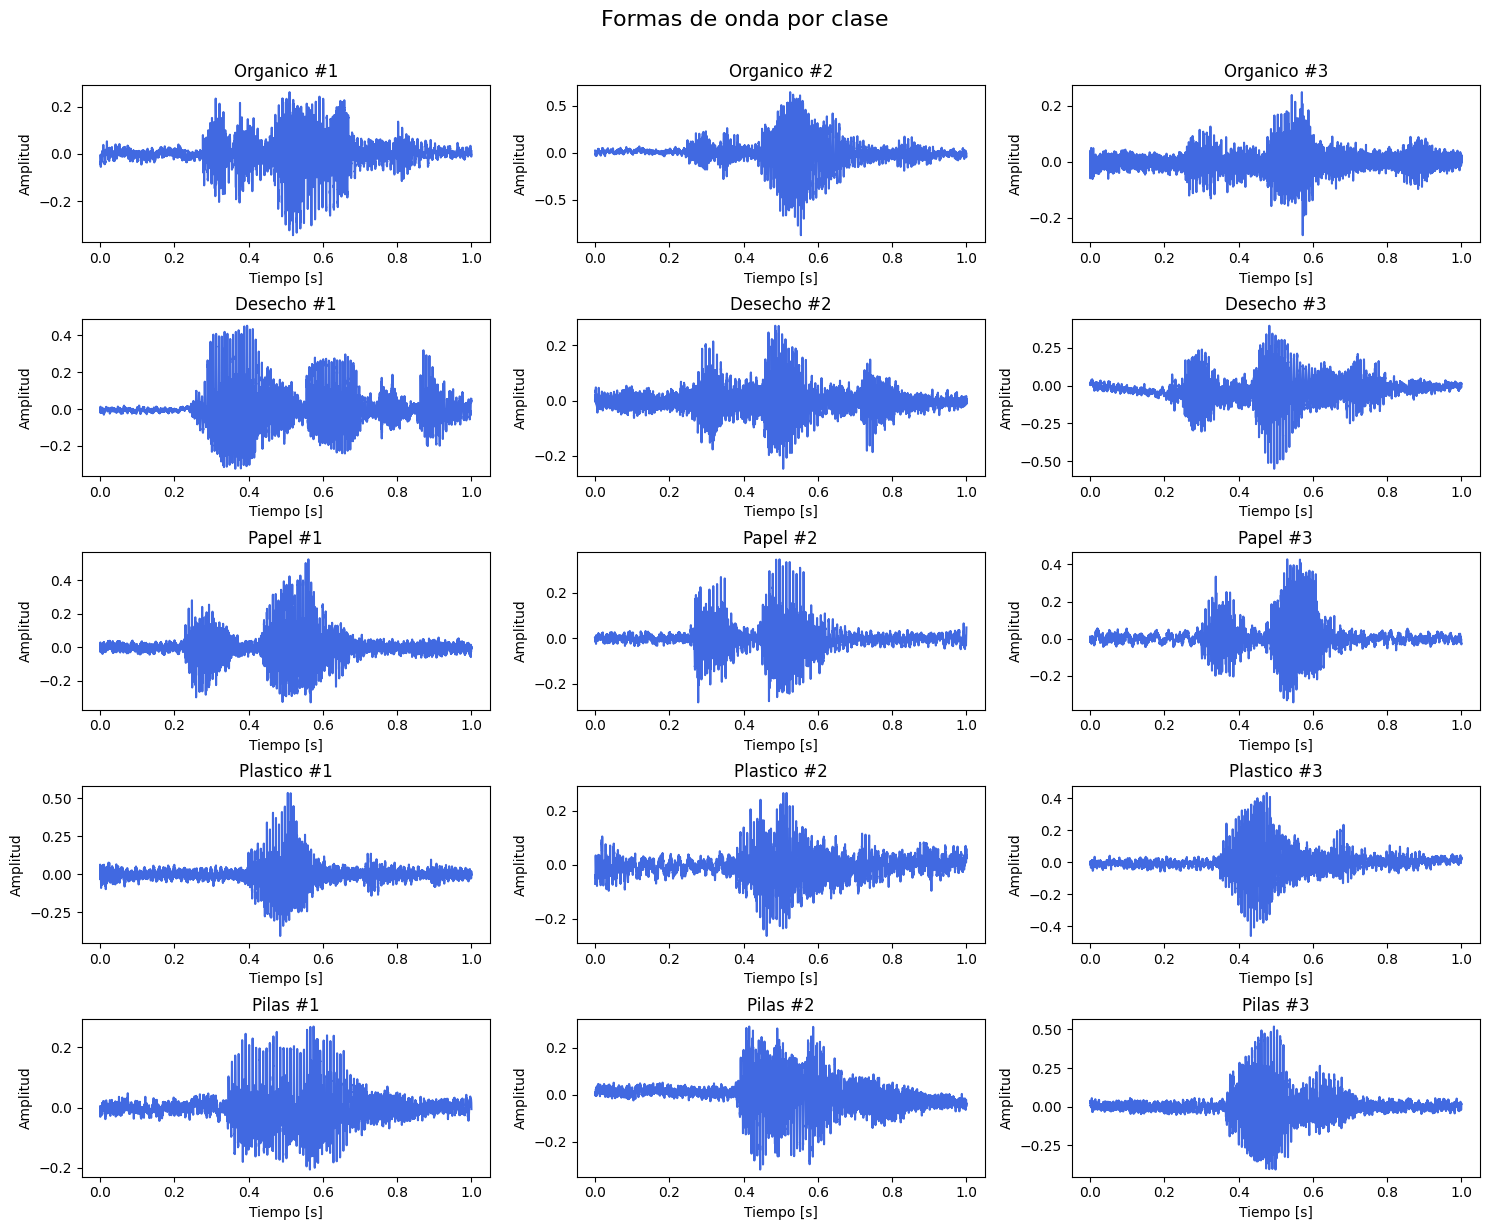

In [ ]:
plt.figure(figsize=(15, len(clases) * 2.5))

for i, clase in enumerate(clases):
  indices = np.where(LabelsTrainfin == i)[0]
  seleccionados = np.random.choice(indices, muestras_por_clase, replace=False)

  for j, idx in enumerate(seleccionados):
    plt_idx = i * muestras_por_clase + j + 1
    plt.subplot(len(clases), muestras_por_clase, plt_idx)
    plt.plot(tiempo, DatosTrainfin[idx], color='royalblue')
    plt.title(f"{clase} #{j+1}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.tight_layout()

plt.suptitle("Formas de onda por clase", fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()

# Espectograma

## Preprocess

In [ ]:
def load_wav_16k_mono(filename):
  # Load encoded wav file
  file_contents = tf.io.read_file(filename)
  # Decode wav (tensors by channels)
  wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
  # Removes trailing axis
  wav = tf.squeeze(wav, axis=-1)
  return wav

In [ ]:
def preprocess(wave):
  #wav = wave[:32000]
  wav = wave[:16000]
  #zero_padding = tf.zeros([48000] - tf.shape(wav), dtype=tf.float32)
  # wav = tf.concat([zero_padding, wav],0)
  spectrogram = tf.signal.stft(wav, frame_length=255, frame_step=128)
  spectrogram = tf.abs(spectrogram)
  return spectrogram

In [ ]:
files = os.listdir(base_path)
files.sort()
cantidadFiles = len(files)
# Variable donde se almacenaron los datos leidos de los archivos *.json
#Datos=np.zeros((cantidadFiles*624,3))
Datos=np.zeros((cantidadFiles,124,129))
i = 0
for file in files:
  if file.endswith(".wav"): # Only process files ending with .wav
    RutaFile=base_path + file
    wave = load_wav_16k_mono(RutaFile)
    espectrograma= preprocess(wave)
    Datos[i,:,:]=espectrograma
    i+=1
print(Datos.shape)

(246, 124, 129)


In [ ]:
les = os.listdir(base_path)
files.sort()
cantidadFiles = len(files)

(16000,)


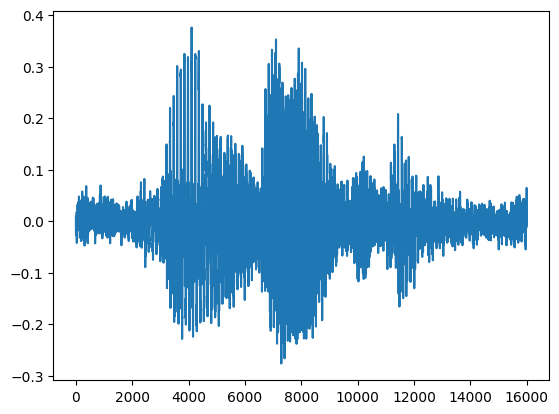

In [ ]:
RutaFile= f"{base_path}/Desecho.5oi5f3r6.ingestion-7bd4d7767c-8xhnz.s1.wav"
wave = load_wav_16k_mono(RutaFile)
print(wave.shape)
plt.plot(wave)
plt.show()

Waveform shape: (16000,)
Spectrogram shape: (124, 129)
Audio playback


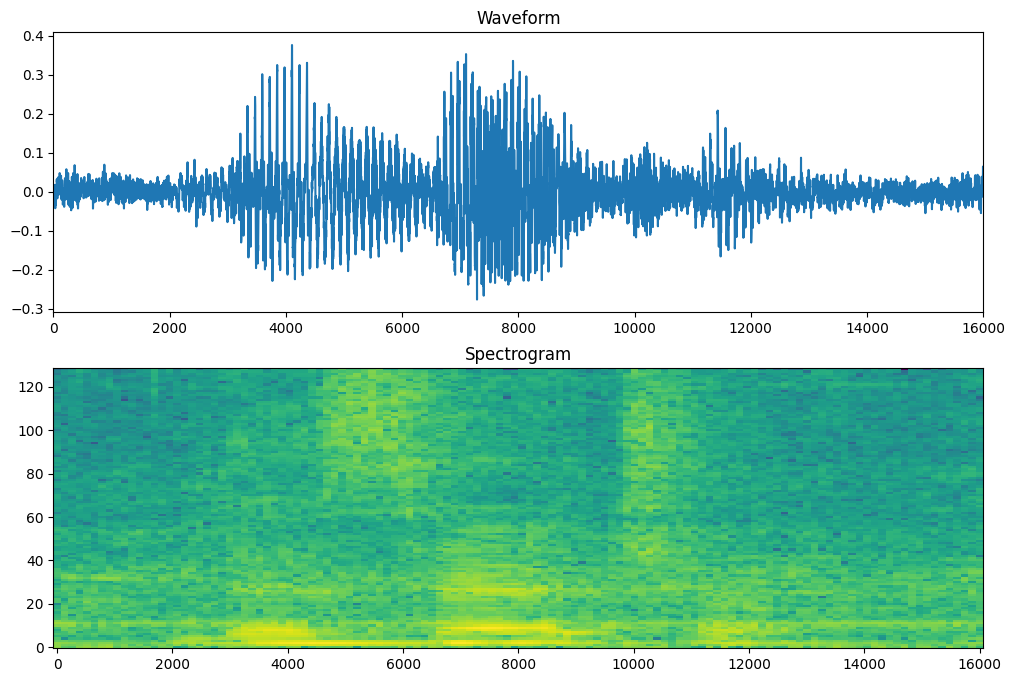

In [ ]:
espectrograma= preprocess(wave)
print('Waveform shape:', wave.shape)
print('Spectrogram shape:', espectrograma.shape)
print('Audio playback')
display(Audio(wave.numpy(), rate=16000))

def plot_spectrogram(espectrograma, ax):
  # Convert to frequencies to log scale and transpose so that the time is represented in the x-axis (columns).
  log_spec = np.log(espectrograma.T)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(espectrograma), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(wave.shape[0])
axes[0].plot(timescale, wave.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])
plot_spectrogram(espectrograma.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.show()

## Modelado

In [ ]:
def extraer_espectrograma(y, sr=16000, n_fft=512, hop_length=256):
  # Espectrograma de magnitud
  S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
  # Convertir a escala logarítmica (dB)
  S_db = librosa.amplitude_to_db(S, ref=np.max)
  return S_db.T  # Transponer a (frames, bins)

In [ ]:
Espectros = []

for i in range(Datosfin.shape[0]):
  espectro = extraer_espectrograma(Datosfin[i])
  Espectros.append(espectro)

Espectros = np.array(Espectros)
Labelsfin = np.array(Labelsfin)

print("Shape espectrogramas:", Espectros.shape)

Shape espectrogramas: (245, 63, 257)


In [ ]:
X = Espectros[..., np.newaxis]
y = Labelsfin

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

In [ ]:
def extraer_mel_espectrograma(y, sr=16000, n_fft=512, hop_length=256, n_mels=128):
  S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
  S_db = librosa.power_to_db(S, ref=np.max)
  return S_db.T

In [ ]:
model = Sequential([
  Conv2D(256, (3, 3), activation='relu', input_shape=X.shape[1:], padding='same'),
  BatchNormalization(),
  Conv2D(64, (3, 3), activation='relu', padding='same'),
  MaxPooling2D(pool_size=(2, 2)),
  Dropout(0.25),

  Conv2D(128, (3, 3), activation='relu', padding='same'),
  BatchNormalization(),
  Conv2D(128, (3, 3), activation='relu', padding='same'),
  MaxPooling2D(pool_size=(2, 2)),
  Dropout(0.25),

  Conv2D(256, (3, 3), activation='relu', padding='same'),
  BatchNormalization(),
  MaxPooling2D(pool_size=(2, 2)),
  Dropout(0.25),

  Flatten(),
  Dense(256, activation='relu'),
  Dropout(0.25),
  Dense(64, activation='relu'),
  Dropout(0.25),
  Dense(len(clases), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('mejor_modelo_mel.h5', save_best_only=True, monitor='val_accuracy')

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 63, 257, 256)   │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 257, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 63, 257, 64)    │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 128, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 31, 128, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 31, 128, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57344)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    14,680,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,366,341 (58.62 MB)

 Trainable params: 15,365,061 (58.61 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
model.fit(X_train, y_train, epochs=300, batch_size=16, validation_data=(X_test, y_test), callbacks=[early, checkpoint])

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1769 - loss: 12.7515  

13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.1796 - loss: 12.5181 - val_accuracy: 0.1837 - val_loss: 12.1033
Epoch 2/300
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3880 - loss: 2.5692

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.3909 - loss: 2.5281 - val_accuracy: 0.2041 - val_loss: 11.1022
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.5583 - loss: 1.5779 - val_accuracy: 0.2041 - val_loss: 13.3865
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6623 - loss: 1.0424 - val_accuracy: 0.2041 - val_loss: 13.5629
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.7058 - loss: 1.0311 - val_accuracy: 0.2041 - val_loss: 14.4123
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.7925 - loss: 0.6411 - val_accuracy: 0.2041 - val_loss: 9.5141
Epoch 7/300
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8300 - loss: 0.5368

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.8317 - loss: 0.5272 - val_accuracy: 0.4286 - val_loss: 3.0456
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.8304 - loss: 0.4573 - val_accuracy: 0.3469 - val_loss: 2.4672
Epoch 9/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.8226 - loss: 0.4423 - val_accuracy: 0.4286 - val_loss: 1.8669
Epoch 10/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.8984 - loss: 0.2591 - val_accuracy: 0.3878 - val_loss: 2.4595
Epoch 11/300
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9521 - loss: 0.1733

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.9494 - loss: 0.1766 - val_accuracy: 0.4694 - val_loss: 2.3339
Epoch 12/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9137 - loss: 0.2371 - val_accuracy: 0.4490 - val_loss: 2.2554
Epoch 13/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9060 - loss: 0.2926 - val_accuracy: 0.4694 - val_loss: 1.8565
Epoch 14/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.8576 - loss: 0.3040 - val_accuracy: 0.4286 - val_loss: 2.3600
Epoch 15/300
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9095 - loss: 0.2824

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.9108 - loss: 0.2799 - val_accuracy: 0.6939 - val_loss: 1.0061
Epoch 16/300
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9562 - loss: 0.1680

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.9559 - loss: 0.1680 - val_accuracy: 0.8163 - val_loss: 1.9400
Epoch 17/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9213 - loss: 0.2270 - val_accuracy: 0.5714 - val_loss: 3.3380
Epoch 18/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9168 - loss: 0.2808 - val_accuracy: 0.5306 - val_loss: 4.7480
Epoch 19/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9412 - loss: 0.1572 - val_accuracy: 0.5510 - val_loss: 4.9245
Epoch 20/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9434 - loss: 0.1609 - val_accuracy: 0.4694 - val_loss: 5.9872
Epoch 21/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9611 - loss: 0.1164 - val_accuracy: 0.3878 - val_loss: 7.9830
Epoch 22/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9664 - loss: 0.1132 - val_accuracy: 0.3265 - val_loss: 8.1347
Epoch 23/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9961 - loss: 0.0273 - val_accuracy: 0.4694

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Precisión test: {acc*100:.2f}% | Pérdida: {loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.6918 - loss: 1.0482
Precisión test: 69.39% | Pérdida: 1.0061


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step


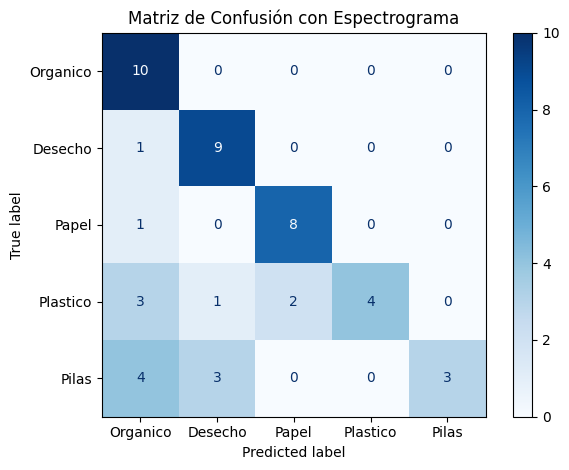

              precision    recall  f1-score   support

    Organico       0.53      1.00      0.69        10
     Desecho       0.69      0.90      0.78        10
       Papel       0.80      0.89      0.84         9
    Plastico       1.00      0.40      0.57        10
       Pilas       1.00      0.30      0.46        10

    accuracy                           0.69        49
   macro avg       0.80      0.70      0.67        49
weighted avg       0.80      0.69      0.67        49



In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión con Espectrograma")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=clases))

In [ ]:
model1 = Sequential([
  Conv2D(256, (3, 3), activation='relu', input_shape=X.shape[1:], padding='same'),
  BatchNormalization(),
  Conv2D(128, (3, 3), activation='relu', padding='same'),
  MaxPooling2D(pool_size=(2, 2)),
  Dropout(0.25),

  Conv2D(64, (3, 3), activation='relu', padding='same'),
  BatchNormalization(),
  Conv2D(64, (3, 3), activation='relu', padding='same'),
  MaxPooling2D(pool_size=(2, 2)),
  Dropout(0.25),

  Conv2D(256, (3, 3), activation='relu', padding='same'),
  BatchNormalization(),
  MaxPooling2D(pool_size=(2, 2)),
  Dropout(0.25),

  Flatten(),
  Dense(256, activation='relu'),
  Dropout(0.25),
  Dense(64, activation='relu'),
  Dropout(0.25),
  Dense(len(clases), activation='softmax')
])

model1.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('mejor_modelo_mel.h5', save_best_only=True, monitor='val_accuracy')

model1.fit(X_train, y_train, epochs=300, batch_size=16, validation_data=(X_test, y_test), callbacks=[early, checkpoint])

Epoch 1/300


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 875ms/step - accuracy: 0.2186 - loss: 3.4324

13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.2194 - loss: 3.4180 - val_accuracy: 0.2041 - val_loss: 1.6766
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 120ms/step - accuracy: 0.2454 - loss: 2.9729 - val_accuracy: 0.2041 - val_loss: 1.8463
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.4192 - loss: 1.8846 - val_accuracy: 0.2041 - val_loss: 1.7929
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.5298 - loss: 1.2995 - val_accuracy: 0.2041 - val_loss: 1.9675
Epoch 5/300
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.6870 - loss: 1.0216

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.6865 - loss: 1.0119 - val_accuracy: 0.2245 - val_loss: 1.9526
Epoch 6/300
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.6534 - loss: 0.8518

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.9284 - loss: 0.1591 - val_accuracy: 0.8571 - val_loss: 0.5257
Epoch 21/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9425 - loss: 0.2018 - val_accuracy: 0.8571 - val_loss: 0.5270
Epoch 22/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9412 - loss: 0.1274 - val_accuracy: 0.8571 - val_loss: 0.4997
Epoch 23/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.9179 - loss: 0.1937 - val_accuracy: 0.8571 - val_loss: 0.4855
Epoch 24/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.9719 - loss: 0.0949 - val_accuracy: 0.8367 - val_loss: 0.5117
Epoch 25/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.9737 - loss: 0.1081 - val_accuracy: 0.8571 - val_loss: 0.4765
Epoch 26/300
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9726 - loss: 0.0940

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.9700 - loss: 0.0987 - val_accuracy: 0.8776 - val_loss: 0.4008
Epoch 27/300
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9725 - loss: 0.0732

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.9706 - loss: 0.0756 - val_accuracy: 0.8980 - val_loss: 0.3651
Epoch 28/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9976 - loss: 0.0249 - val_accuracy: 0.8980 - val_loss: 0.3121
Epoch 29/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9748 - loss: 0.0800 - val_accuracy: 0.8980 - val_loss: 0.3609
Epoch 30/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.9741 - loss: 0.0796 - val_accuracy: 0.8980 - val_loss: 0.2919
Epoch 31/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.9729 - loss: 0.0923 - val_accuracy: 0.8571 - val_loss: 0.3514
Epoch 32/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9812 - loss: 0.0714 - val_accuracy: 0.8571 - val_loss: 0.3489
Epoch 33/300
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9792 - loss: 0.0778

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.9792 - loss: 0.0762 - val_accuracy: 0.9184 - val_loss: 0.2720
Epoch 34/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9753 - loss: 0.0551 - val_accuracy: 0.9184 - val_loss: 0.2862
Epoch 35/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.9924 - loss: 0.0519 - val_accuracy: 0.8980 - val_loss: 0.2751
Epoch 36/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.9775 - loss: 0.0490 - val_accuracy: 0.8980 - val_loss: 0.3147
Epoch 37/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9501 - loss: 0.1163 - val_accuracy: 0.9184 - val_loss: 0.2775
Epoch 38/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9902 - loss: 0.0576 - val_accuracy: 0.8980 - val_loss: 0.2966
Epoch 39/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9835 - loss: 0.0379 - val_accuracy: 0.8980 - val_loss: 0.2721
Epoch 40/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9970 - loss: 0.0265 - val_accuracy:

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.9899 - loss: 0.0228 - val_accuracy: 0.9388 - val_loss: 0.2195
Epoch 44/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.9663 - loss: 0.0864 - val_accuracy: 0.8980 - val_loss: 0.2389
Epoch 45/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9733 - loss: 0.1149 - val_accuracy: 0.9184 - val_loss: 0.2549
Epoch 46/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.9914 - loss: 0.0431 - val_accuracy: 0.9184 - val_loss: 0.2653
Epoch 47/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9868 - loss: 0.0274 - val_accuracy: 0.8776 - val_loss: 0.2885
Epoch 48/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 1.0000 - loss: 0.0211 - val_accuracy: 0.8980 - val_loss: 0.3045
Epoch 49/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 1.0000 - loss: 0.0180 - val_accuracy: 0.8980 - val_loss: 0.2768
Epoch 50/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.9906 - loss: 0.0438 - val_accuracy:

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


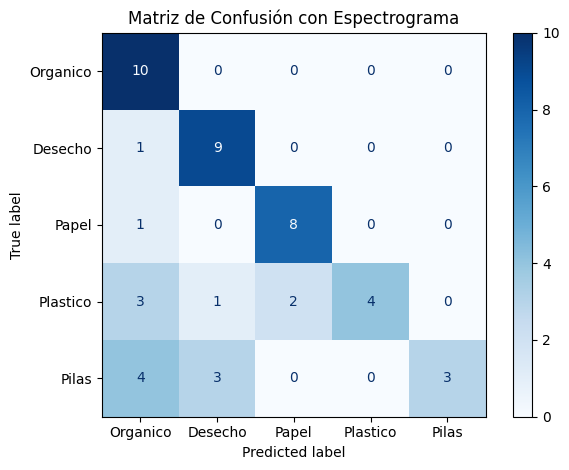

              precision    recall  f1-score   support

    Organico       0.53      1.00      0.69        10
     Desecho       0.69      0.90      0.78        10
       Papel       0.80      0.89      0.84         9
    Plastico       1.00      0.40      0.57        10
       Pilas       1.00      0.30      0.46        10

    accuracy                           0.69        49
   macro avg       0.80      0.70      0.67        49
weighted avg       0.80      0.69      0.67        49



In [ ]:
y_pred1 = np.argmax(model.predict(X_test), axis=1)

cm1 = confusion_matrix(y_test, y_pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=clases)
disp1.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión con Espectrograma")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred1, target_names=clases))

# MFC

## Preprocesamiento

In [ ]:
def extraer_mfcc(data, sr=16000, n_mfcc=13):
  # data: vector 1D de audio
  mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=n_mfcc)
  mfcc = mfcc[1:, :]
  mfcc = mfcc.T  # Transponer (frames, n_mfcc)
  return mfcc

### Training

In [ ]:
Train_MFCCs = []
for i in range(DatosTrainfin.shape[0]):
  mfcc = extraer_mfcc(DatosTrainfin[i])
  Train_MFCCs.append(mfcc)

Train_MFCCs = np.array(Train_MFCCs)
LabelsTrainfin = np.array(LabelsTrainfin)

print("Train_MFCCs shape:", Train_MFCCs.shape)

Train_MFCCs shape: (650, 32, 12)


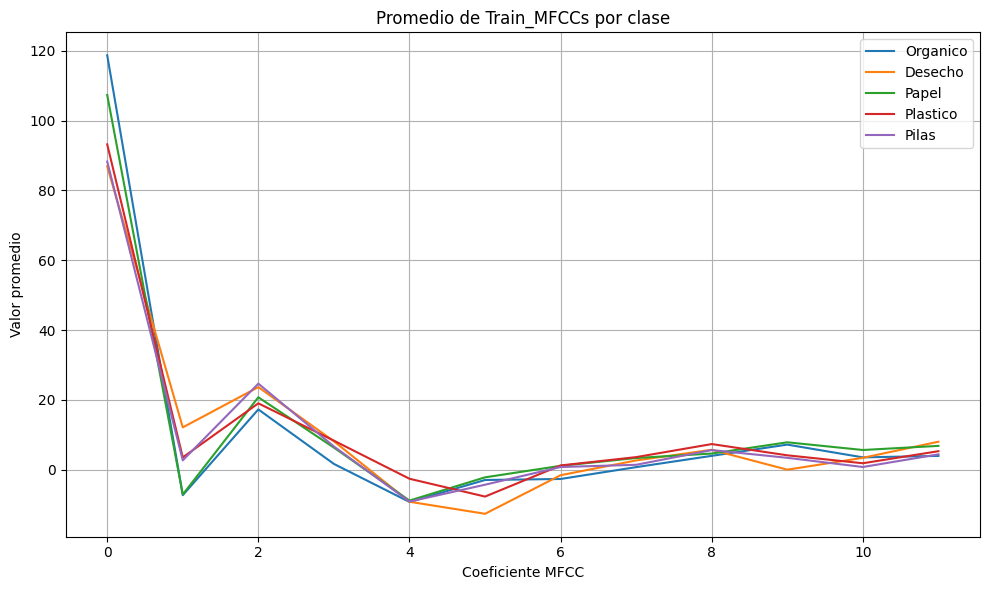

In [ ]:
n_mfcc = Train_MFCCs.shape[2]

plt.figure(figsize=(10, 6))

for idx, clase in enumerate(clases):
  # Filtrar Train_MFCCs por clase
  mfccs_clase = Train_MFCCs[LabelsTrainfin == idx]

  # Promediar por todas las muestras: primero sobre frames, luego sobre muestras
  promedio = mfccs_clase.mean(axis=0).mean(axis=0)  # shape: (n_mfcc,)

  plt.plot(range(n_mfcc), promedio, label=clase)

plt.title("Promedio de Train_MFCCs por clase")
plt.xlabel("Coeficiente MFCC")
plt.ylabel("Valor promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Testing

In [ ]:
Test_MFCCs = []
for i in range(DatosTestfin.shape[0]):
  mfcc = extraer_mfcc(DatosTestfin[i])
  Test_MFCCs.append(mfcc)

Test_MFCCs = np.array(Test_MFCCs)
LabelsTestfin = np.array(LabelsTestfin)

print("Test_MFCCs shape:", Test_MFCCs.shape)

Test_MFCCs shape: (100, 32, 12)


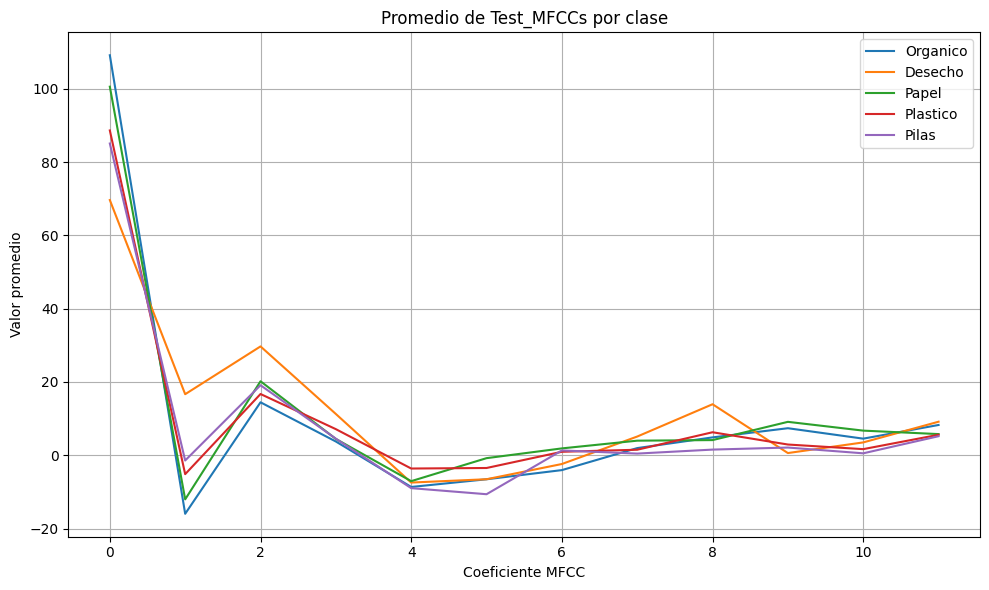

In [ ]:
n_mfcc = Test_MFCCs.shape[2]

plt.figure(figsize=(10, 6))

for idx, clase in enumerate(clases):
  # Filtrar Test_MFCCs por clase
  mfccs_clase = Test_MFCCs[LabelsTestfin == idx]

  # Promediar por todas las muestras: primero sobre frames, luego sobre muestras
  promedio = mfccs_clase.mean(axis=0).mean(axis=0)  # shape: (n_mfcc,)

  plt.plot(range(n_mfcc), promedio, label=clase)

plt.title("Promedio de Test_MFCCs por clase")
plt.xlabel("Coeficiente MFCC")
plt.ylabel("Valor promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Extracción de mejores caracteristicas

In [ ]:
archivos_wav = [f for f in os.listdir(training_base_path) if f.endswith(".wav")]

In [ ]:
archivo_wav = archivos_wav[1]
print(archivo_wav)

Plastico.5ppel6gi.ingestion-54c4c64498-bpmm6.s15.wav


### Grafico MFCC capturado por coefiente

In [ ]:
def graficar_mfcc(y, sr, max_mfcc=40):
  fig, axs = plt.subplots(4, 2, figsize=(15, 15))
  axs = axs.ravel()

  for i, n in enumerate(range(9, max_mfcc+1, 5)):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n)
    img = axs[i].imshow(mfcc, origin='lower', aspect='auto', cmap='viridis')
    axs[i].set_title(f"MFCC con {n} coeficientes")
    fig.colorbar(img, ax=axs[i])

  plt.tight_layout()
  plt.show()

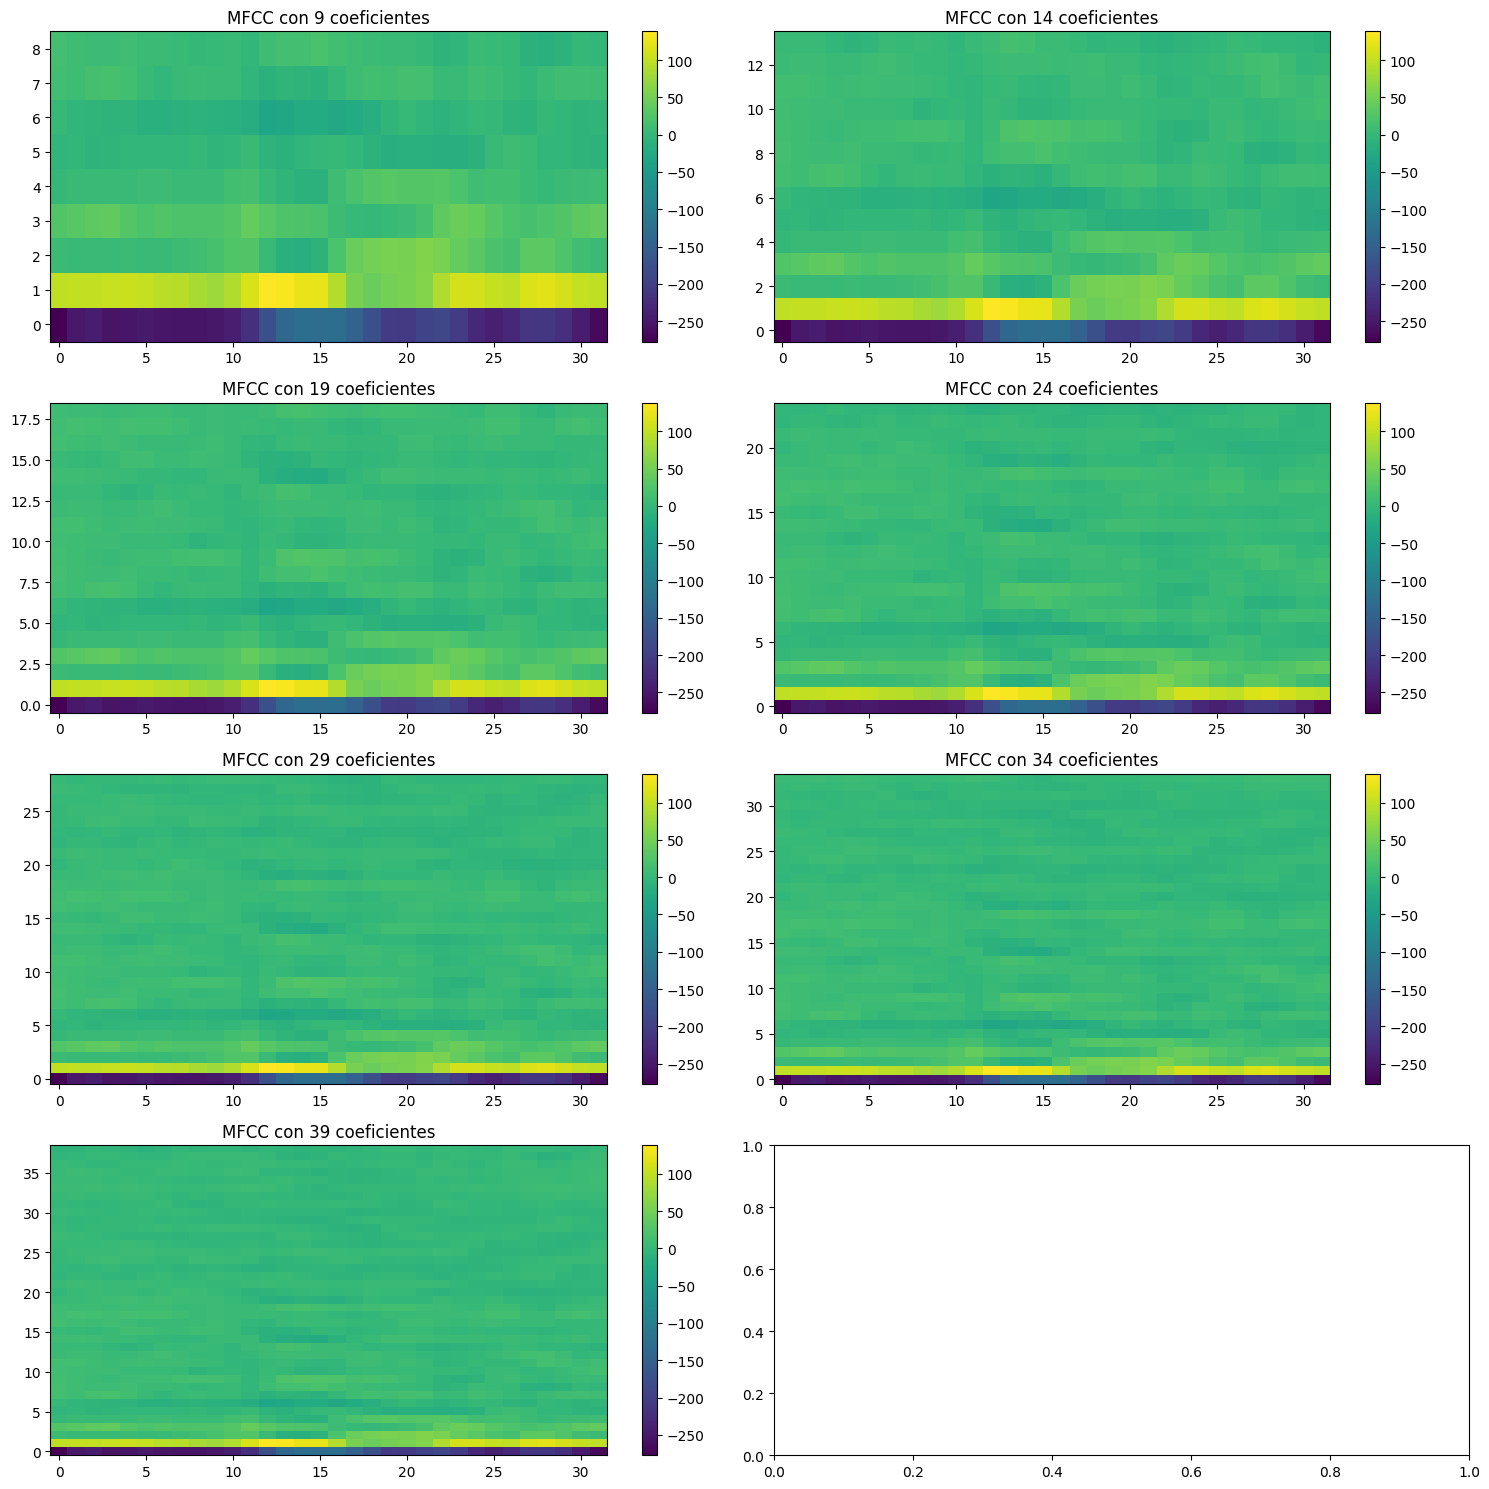

In [ ]:
y, sr = librosa.load(f"{training_base_path}/{archivo_wav}", sr=16000)
graficar_mfcc(y, sr)

### Varianza capturada por coeficiente

In [ ]:
n_max = 20
mfcc_full = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_max)
varianza = np.var(mfcc_full, axis=1)

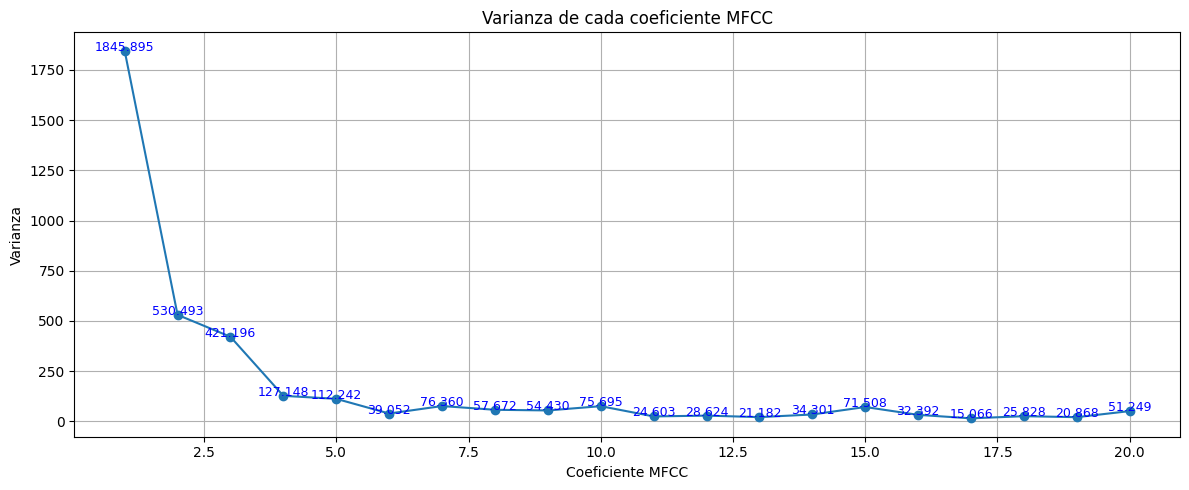

In [ ]:
plt.figure(figsize=(12, 5))
x = range(1, n_max + 1)
plt.plot(x, varianza, marker='o')
plt.title("Varianza de cada coeficiente MFCC")
plt.xlabel("Coeficiente MFCC")
plt.ylabel("Varianza")
plt.grid(True)

for i, v in enumerate(varianza):
  plt.text(x[i], v + 0.001, f"{v:.3f}", ha='center', fontsize=9, color='blue')

plt.tight_layout()
plt.show()

### Resultados

In [ ]:
n_mfcc = 8

## Detección de anomalías

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

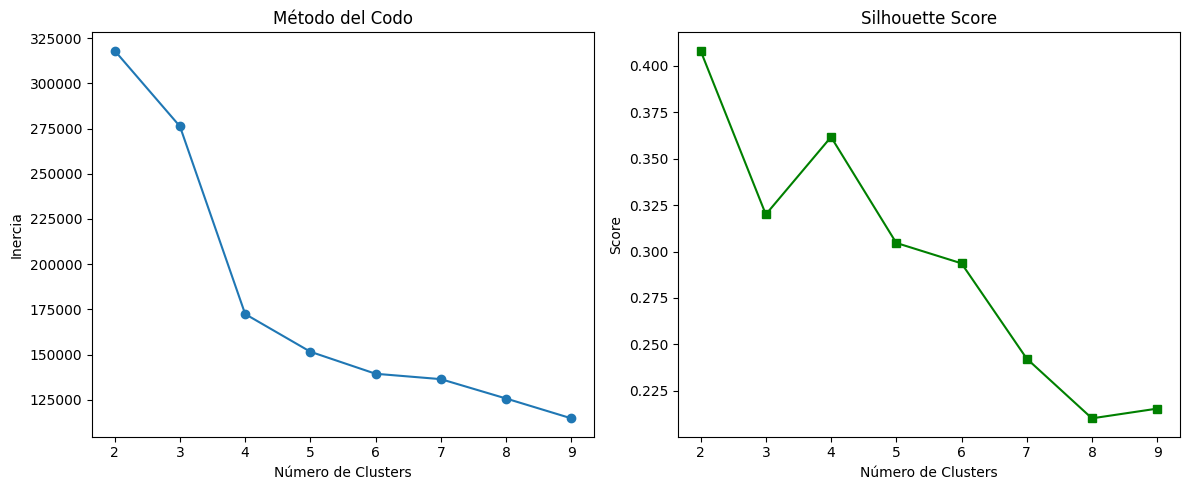

In [ ]:
X = np.mean(Train_MFCCs, axis=1)  # Asegúrate que esté 2D (samples x features)
inertia = []
silhouette_scores = []
K = range(2, 10)

for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
  inertia.append(kmeans.inertia_)
  score = silhouette_score(X, kmeans.labels_)
  silhouette_scores.append(score)

# Gráficos
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(K, inertia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker='s', color='green')
plt.title('Silhouette Score')
plt.xlabel('Número de Clusters')
plt.ylabel('Score')

plt.tight_layout()
plt.show()

Escogemos 5 clusters

## Modelado

### Preprocesamiento

In [ ]:
unique_labels = np.unique(LabelsTrainfin)
num_classes = len(unique_labels)

In [ ]:
X_train = Train_MFCCs[..., np.newaxis]
y_train = LabelsTrainfin
X_test = Test_MFCCs[..., np.newaxis]
y_test = LabelsTestfin

label_mapping = {label: i for i, label in enumerate(unique_labels)}
y_train = np.array([label_mapping[label] for label in LabelsTrainfin])
y_test = np.array([label_mapping[label] for label in LabelsTestfin])
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
  X_train, y_train, stratify=y_train, test_size=0.2, random_state=42
)

### Modelo entrenamiento

In [ ]:
model = Sequential([
  # Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
  Conv2D(64, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
  MaxPooling2D((2, 2)),
  # Conv2D(128, (3, 3), activation='relu'),
  Conv2D(32, (3, 3), activation='relu'),
  MaxPooling2D((2, 2)),
  Flatten(),
  Dense(64, activation='relu'),
  Dropout(0.3),
  Dense(32, activation='relu'),
  Dense(len(clases), activation='softmax'),
])

# Lets aggregate callback y earlystopping
early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('mejor_modelo_mfcc.h5', save_best_only=True, monitor='val_accuracy')

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 10, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 5, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 3, 32)      │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,701 (131.64 KB)

 Trainable params: 33,701 (131.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=300, validation_data=(X_val, y_val), batch_size=32, callbacks=[early, checkpoint])

Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.3110 - loss: 2.5004

17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 188ms/step - accuracy: 0.3162 - loss: 2.4604 - val_accuracy: 0.6462 - val_loss: 0.9531
Epoch 2/300
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5938 - loss: 1.0558

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6533 - loss: 0.9165 - val_accuracy: 0.9308 - val_loss: 0.3371
Epoch 3/300
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7500 - loss: 0.6228

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8175 - loss: 0.5613 - val_accuracy: 0.9538 - val_loss: 0.1817
Epoch 4/300
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9062 - loss: 0.2511

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8715 - loss: 0.3402 - val_accuracy: 0.9615 - val_loss: 0.1216
Epoch 5/300
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8750 - loss: 0.2314

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9418 - loss: 0.1856 - val_accuracy: 0.9846 - val_loss: 0.0787
Epoch 6/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9579 - loss: 0.1499 - val_accuracy: 0.9846 - val_loss: 0.0810
Epoch 7/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9472 - loss: 0.1426 - val_accuracy: 0.9846 - val_loss: 0.0639
Epoch 8/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9507 - loss: 0.1356 - val_accuracy: 0.9769 - val_loss: 0.0730
Epoch 9/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9668 - loss: 0.1030 - val_accuracy: 0.9692 - val_loss: 0.1017
Epoch 10/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9601 - loss: 0.1234 - val_accuracy: 0.9769 - val_loss: 0.0630
Epoch 11/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9854 - loss: 0.0560 - val_accuracy: 0.9615 - val_loss: 0.0751
Epoch 12/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9755 - loss: 0.0728 - val_accuracy: 0.9769 - val_loss: 

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9927 - loss: 0.0398 - val_accuracy: 0.9923 - val_loss: 0.0495
Epoch 16/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9945 - loss: 0.0298 - val_accuracy: 0.9692 - val_loss: 0.0651
Epoch 17/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9938 - loss: 0.0226 - val_accuracy: 0.9769 - val_loss: 0.0739
Epoch 18/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0107 - val_accuracy: 0.9769 - val_loss: 0.0651
Epoch 19/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9952 - loss: 0.0224 - val_accuracy: 0.9769 - val_loss: 0.0484
Epoch 20/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0152 - val_accuracy: 0.9923 - val_loss: 0.0226
Epoch 21/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9949 - loss: 0.0162 - val_accuracy: 0.9769 - val_loss: 0.0770
Epoch 22/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9892 - loss: 0.0264 - val_accuracy: 0.9846 - val_lo

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Precisión test: {acc*100:.2f}% | Pérdida: {loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.9724 - loss: 0.1141
Precisión test: 97.00% | Pérdida: 0.1409


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step


<Figure size 800x600 with 0 Axes>

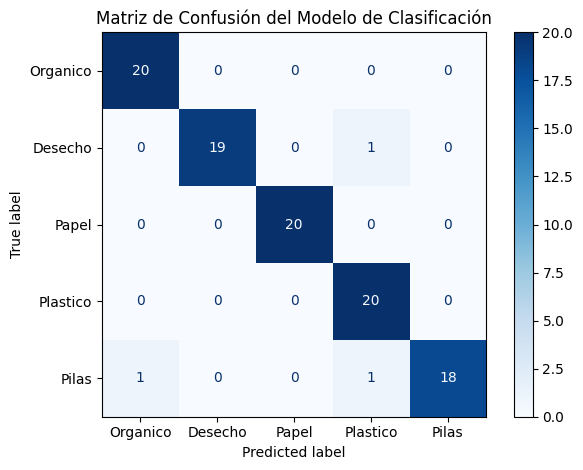

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert y_test to single-label format
y_test_single_label = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_single_label, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión del Modelo de Clasificación")
plt.tight_layout()
plt.show()

In [ ]:
# save model
model.save('mejor_modelo_mfcc.h5')

# Exportar

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

Saved artifact at '/tmp/tmpv3cjehnn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 12, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134320956707024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956708176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956705488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956716048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956710672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956712592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956710864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956717968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956716240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956717584: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
with open("audio_classifier.tflite", "wb") as f:
  f.write(tflite_model)

In [ ]:
# Conviertir .tflite a C array con xxd
!xxd -i audio_classifier.tflite > audio_model_data.h

### LITE

In [ ]:
converter2 = tf.lite.TFLiteConverter.from_keras_model(model)
converter2.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter2.convert()
# Se guarda el modelo de Tflitecuantizado
open("comandos_model_quant.tflite", "wb").write(tflite_model)

Saved artifact at '/tmp/tmpsnptoj_8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 12, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134320956707024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956708176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956705488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956716048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956710672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956712592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956710864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956717968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956716240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956717584: TensorSpec(shape=(), dtype=tf.resource, name=None)


41800

In [ ]:
# Leer el archivo para hacer la predicción con comandos_model_quant.tflite
interpreter2 = tf.lite.Interpreter(model_path="comandos_model_quant.tflite")
interpreter2.allocate_tensors()

input_details = interpreter2.get_input_details()
output_details = interpreter2.get_output_details()

input_shape = input_details[0]['shape']

num_test_samples = X_test.shape[0]
y_pred_probs = []

for i in range(num_test_samples):
  input_data = X_test[i:i+1].astype(np.float32)
  interpreter2.set_tensor(input_details[0]['index'], input_data)
  interpreter2.invoke()
  output_data = interpreter2.get_tensor(output_details[0]['index'])
  y_pred_probs.append(output_data[0])

y_pred_lite = np.argmax(y_pred_probs, axis=1)

<Figure size 800x600 with 0 Axes>

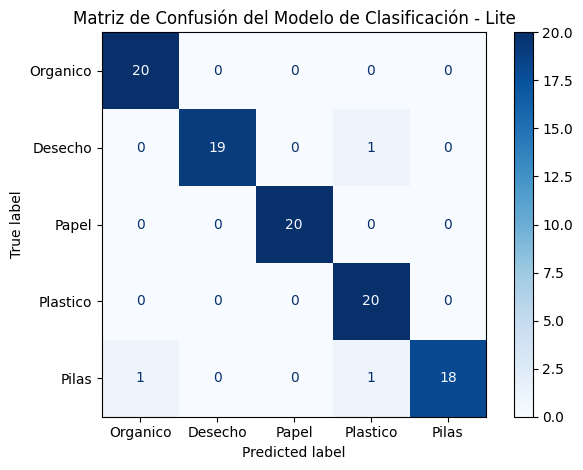

In [ ]:
cm = confusion_matrix(y_test_single_label, y_pred_lite)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión del Modelo de Clasificación - Lite")
plt.tight_layout()
plt.show()

### LITE + QUANT

In [ ]:
converter3 = tf.lite.TFLiteConverter.from_keras_model(model)
converter3.optimizations = [tf.lite.Optimize.DEFAULT]
converter3.target_spec.supported_types = [tf.float16]
tflite_quant_model_3 = converter3.convert()
# Se guarda el modelo de Tflite a 16 bits
open("comandos_model_quant_16.tflite", "wb").write(tflite_quant_model_3)

Saved artifact at '/tmp/tmpzy0vwsmt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 12, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134320956707024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956708176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956705488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956716048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956710672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956712592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956710864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956717968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956716240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134320956717584: TensorSpec(shape=(), dtype=tf.resource, name=None)


72348

In [ ]:
# Leer el archivo para hacer la predicción con comandos_model_quant.tflite
interpreter3 = tf.lite.Interpreter(model_path="comandos_model_quant_16.tflite")
interpreter3.allocate_tensors()

input_details = interpreter3.get_input_details()
output_details = interpreter3.get_output_details()

input_shape = input_details[0]['shape']

num_test_samples = X_test.shape[0]
y_pred_probs = []

for i in range(num_test_samples):
  input_data = X_test[i:i+1].astype(np.float32)
  interpreter3.set_tensor(input_details[0]['index'], input_data)
  interpreter3.invoke()

  output_data = interpreter3.get_tensor(output_details[0]['index'])
  y_pred_probs.append(output_data[0])

y_pred_quant = np.argmax(y_pred_probs, axis=1)

<Figure size 800x600 with 0 Axes>

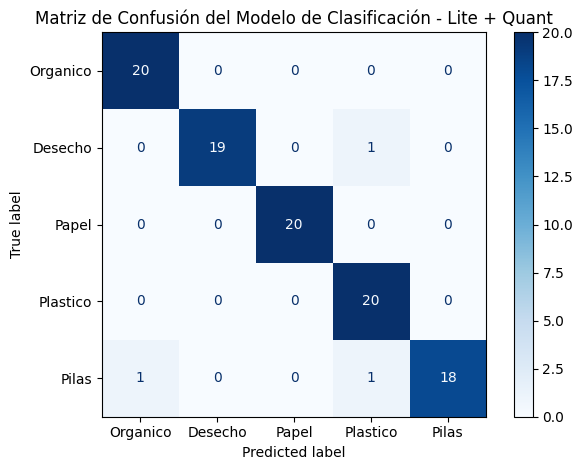

In [ ]:
cm = confusion_matrix(y_test_single_label, y_pred_quant)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión del Modelo de Clasificación - Lite + Quant")
plt.tight_layout()
plt.show()

### Compare model original and model interpreters

In [ ]:
import time

In [ ]:
runs = 100

#### Modelo original

In [ ]:
input_sample = X_test[0:1]  # 1 sola muestra
start = time.time()
for _ in range(runs):
  _ = model.predict(input_sample)
end = time.time()
latency_tf = (end - start) / runs * 1000  # En milisegundos

acc_keras = accuracy_score(y_test_single_label, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━

#### Modelo TFLite (interpreter2)

In [ ]:
input_details = interpreter2.get_input_details()
output_details = interpreter2.get_output_details()
interpreter2.allocate_tensors()
input_sample = X_test[0:1].astype(np.float32)

start = time.time()
for _ in range(runs):
  interpreter2.set_tensor(input_details[0]['index'], input_sample)
  interpreter2.invoke()
  _ = interpreter2.get_tensor(output_details[0]['index'])
end = time.time()
latency_lite = (end - start) / runs * 1000

acc_lite = accuracy_score(y_test_single_label, y_pred_lite)

#### Modelo TFLite con float16 (interpreter3)

In [ ]:
input_details = interpreter3.get_input_details()
output_details = interpreter3.get_output_details()
interpreter3.allocate_tensors()
input_sample = X_test[0:1].astype(np.float32)

start = time.time()
for _ in range(runs):
  interpreter3.set_tensor(input_details[0]['index'], input_sample)
  interpreter3.invoke()
  _ = interpreter3.get_tensor(output_details[0]['index'])
end = time.time()
latency_quant = (end - start) / runs * 1000

acc_quant = accuracy_score(y_test_single_label, y_pred_quant)

#### Resultados Latencia

In [ ]:
print(f"TF original: {latency_tf:.2f} ms")
print(f"Accuracy - Modelo Keras original: {acc_keras:.4f}")
print("-"*10)
print(f"TFLite: {latency_lite:.2f} ms")
print(f"Accuracy - Modelo TFLite: {acc_lite:.4f}")
print("-"*10)
print(f"TFLite + Quant (float16): {latency_quant:.2f} ms")
print(f"Accuracy - Modelo TFLite + Quant (float16): {acc_quant:.4f}")

TF original: 77.45 ms
Accuracy - Modelo Keras original: 0.9700
----------
TFLite: 0.06 ms
Accuracy - Modelo TFLite: 0.9700
----------
TFLite + Quant (float16): 0.07 ms
Accuracy - Modelo TFLite + Quant (float16): 0.9700


Confirmamos que los 3 modelos presentan el mismo accuracy, lo que vimos en la matriz de confusión.